In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps
from simpeg.potential_fields import magnetics

write_output = False

import torch

### **Crear modelo de SimPEG**



In [2]:
dx = 260 
ncx = 50 
dy = 275 
ncy = 40 
dz = 225 
ncz = 45 


hx = [(dx, ncx)]
hy = [(dy, ncy)]
hz = [(dz, ncz)]
mesh = TensorMesh([hx, hy, hz], x0=[4729500,2048000,-6000])

In [3]:
mesh

TensorMesh: 90,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     50  4,729,500.00  4,742,500.00    260.00    260.00    1.00
   y     40  2,048,000.00  2,059,000.00    275.00    275.00    1.00
   z     45     -6,000.00      4,125.00    225.00    225.00    1.00

In [4]:
model_npz =  np.load("../../../../models/modelE/mag_modelE.npz")

model = model_npz["Mag_model"]
cell_centers = model_npz["cell_centers"]    # (nx, ny, nz), bool
dx = model_npz["dx"]                      # (nx, ny, nz)
dy = model_npz["dy"]                      # (nx, ny, nz)
dz = model_npz["dz"]                      # (nx, ny, nz)

receiver_location = np.load("receivers_modelE.npy")

In [5]:
cell_centers.shape

(90000, 3)

In [6]:
np.unique(model)

array([-0.1, -0.1, -0.1, ...,  0.1,  0.1,  nan], shape=(67771,))

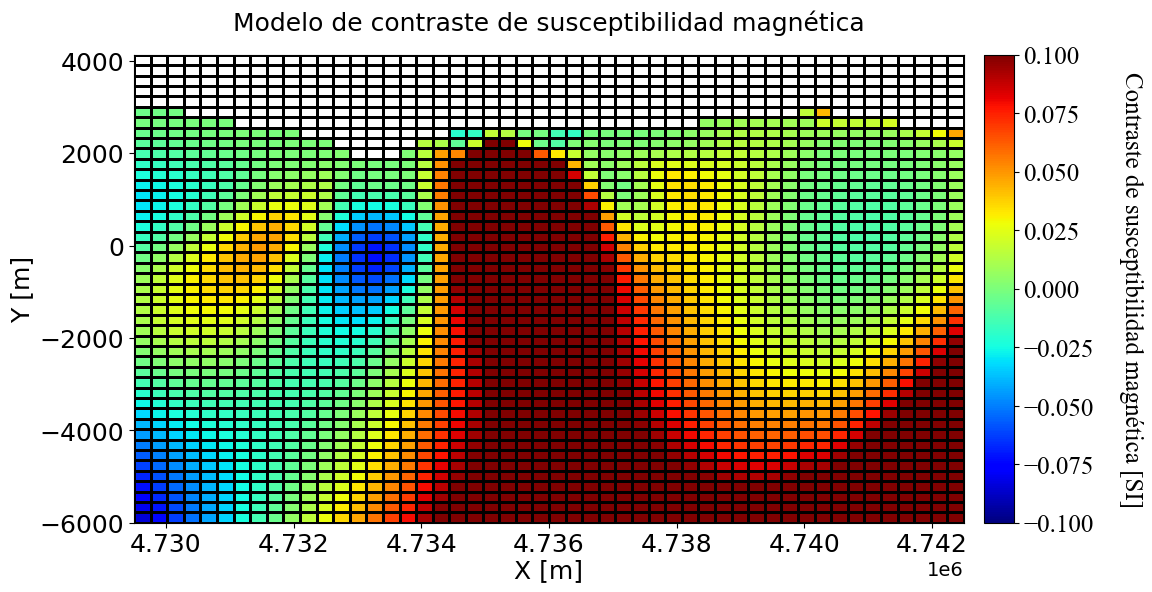

In [7]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_axes([0.1, 0.12, 0.83, 0.78])
mpl.rcParams["font.family"] = "Times New Roman"

m = model   # Contraste de densidad en kg/m^3

# Calculate the y-coordinate of the slice (center of the mesh in Y-direction)
y_slice_coord = mesh.x0[1] + mesh.h[1].sum() / 2

mesh.plot_slice(
    m,
    normal="Y",
    ax=ax1,
    #slice_loc=2056000,
    grid=True,
    clim=(np.nanmin(m), np.nanmax(m)),
    pcolor_opts={"cmap": "jet"},
)
ax1.set_title(f"Modelo de contraste de susceptibilidad magnética", size=18, pad=18)
ax1.set_xlabel("X [m]", size=18, labelpad=1)
ax1.set_ylabel("Y [m]", size=18)
ax1.tick_params(axis="both", which="major", labelsize=18)

# Offset text (ej: 1e6) en ambos ejes
ax1.xaxis.get_offset_text().set_size(14)
ax1.yaxis.get_offset_text().set_size(14)
# Colorbar
ax2 = fig.add_axes([0.95, 0.12, 0.03, 0.78])
norm = mpl.colors.Normalize(vmin=np.nanmin(m), vmax=np.nanmax(m))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.jet
)

cbar.set_label(
    r"Contraste de susceptibilidad magnética [SI]",
    rotation=270,
    labelpad=35,
    fontsize=18
)
cbar.ax.tick_params(labelsize=14)  # ticks del colorbar
cbar.ax.yaxis.get_offset_text().set_size(14)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)


tick_fs = 18     
label_fs = 22    
title_fs = 22    

plt.show()

out_png = "ModelE_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [8]:
y_slice = mesh.x0[1] + mesh.h[1].sum()/2
print(y_slice)

2053500.0


In [9]:
ind_active = ~np.isnan(model)        # (nC,) booleano
n_active = ind_active.sum()

In [10]:
ind_active

array([ True,  True,  True, ..., False, False, False], shape=(90000,))

In [11]:
n_active

np.int64(74727)

In [12]:
model_map = maps.IdentityMap(nP=n_active)

In [13]:
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_location, components=components)

receiver_list = [receiver_list]

# Define the inducing field H0 = (intensity [nT], inclination [deg], declination [deg])
inclination = 24
declination = -2
strength = 30151

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=strength,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

In [14]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
)

In [15]:
model_active = model[~np.isnan(model)]

In [16]:
model_active = model[~np.isnan(model)]
np.unique(model_active)


array([-0.1, -0.1, -0.1, ...,  0.1,  0.1,  0.1], shape=(67770,))

In [17]:
model_active.shape

(74727,)

In [18]:
dpred = simulation.dpred(model_active)

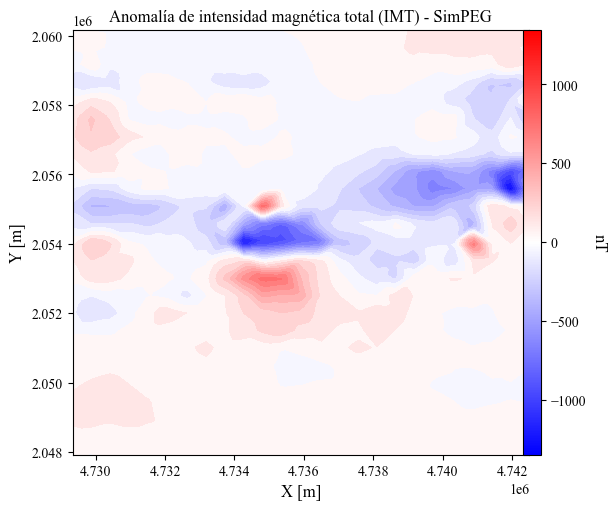

In [19]:
# Plot
fig = plt.figure(figsize=(6, 5))
v_max = np.max(np.abs(dpred))

ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=30,
    clim=(-v_max, v_max),
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Anomalía de intensidad magnética total (IMT) - SimPEG")
ax1.set_xlabel("X [m]", size=12)
ax1.set_ylabel("Y [m]", size=12)

ax2 = fig.add_axes([0.87, 0.1, 0.03, 0.85])
norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dpred)), vmax=np.max(np.abs(dpred)))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("nT", rotation=270, labelpad=15, size=12)

plt.show()

out_png = "Modeling_modelE_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [20]:
obs_xyz_np = np.asarray(receiver_location, float)
resp_np    = np.asarray(dpred, float).reshape(-1)

if obs_xyz_np.ndim != 2 or obs_xyz_np.shape[1] != 3:
    raise ValueError(f"obs_xyz debe ser (nObs,3). Llegó: {obs_xyz_np.shape}")
if resp_np.size != obs_xyz_np.shape[0]:
    raise ValueError(f"Respuesta y obs no coinciden: {resp_np.size} vs {obs_xyz_np.shape[0]}")

out = np.column_stack([obs_xyz_np, resp_np])  # (nObs,4)

np.save("response_modelE_SimPEG.npy", out)

In [21]:
simpeg = np.load("response_modelE_SimPEG.npy")
op = np.load("../Mag_modelE/response_modelE.npy")

In [22]:
re = dpred - op[:,-1]
np.max(re)

np.float64(84.32162487709743)

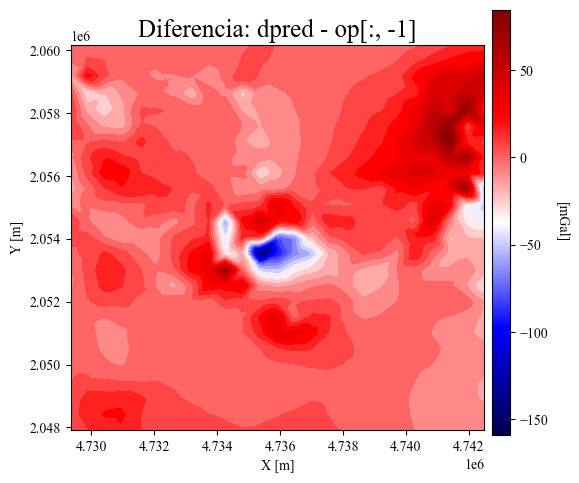

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


difference = dpred - op[:, -1]

locs = receiver_list[0].locations 

vmin = np.nanmin(difference)
vmax = np.nanmax(difference)


fig, ax = plt.subplots(figsize=(6, 5))

plot2Ddata(locs, difference, ax=ax, ncontour=30, clim=(vmin, vmax), contourOpts={"cmap": "seismic"})

ax.set_title("Diferencia: dpred - op[:, -1]", fontsize=18)
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(ax=fig.add_axes([0.87, 0.1, 0.03, 0.85]), norm=norm, orientation="vertical", cmap=mpl.cm.seismic)
cbar.set_label("[mGal]", rotation=270, labelpad=15)

plt.show()

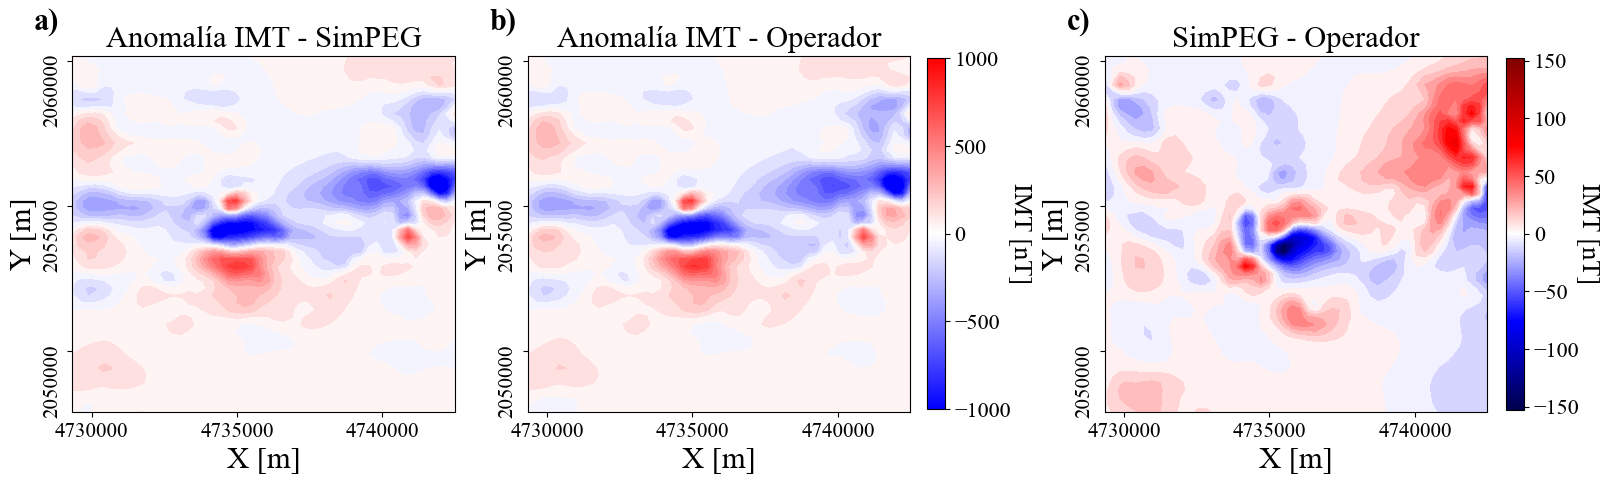

In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

mpl.rcParams["font.family"] = "Times New Roman"

op = np.asarray(op)
simpeg = np.asarray(simpeg)

xy_op = op[:, :2]
val_op = op[:, 2].ravel()

# simpeg: (x, y, z, val)
xy_sp = simpeg[:, :2]
val_sp = simpeg[:, 3].ravel()

if val_op.size != val_sp.size:
    raise ValueError(f"Size mismatch: operator={val_op.size} vs simpeg={val_sp.size}")

# -------- Residual (pointwise, assumes same receiver ordering!) --------
residual = val_sp - val_op

# -------- Common grid (use union bounds so both fit) --------
nx, ny = 50, 50
xmin = min(xy_op[:,0].min(), xy_sp[:,0].min())
xmax = max(xy_op[:,0].max(), xy_sp[:,0].max())
ymin = min(xy_op[:,1].min(), xy_sp[:,1].min())
ymax = max(xy_op[:,1].max(), xy_sp[:,1].max())

xlin = np.linspace(xmin, xmax, nx)
ylin = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xlin, ylin)

# Interpolation (linear is more stable; change to "cubic" if you really want)
method = "cubic"

Z_sp = griddata(xy_sp, val_sp, (X, Y), method=method)
Z_op = griddata(xy_op, val_op, (X, Y), method=method)
Z_rs = Z_sp - Z_op   # residual on the grid (more consistent visually)

# -------- Color ranges --------
vmin, vmax = -1000, 1000            # match your single plot
rmax = np.nanmax(np.abs(Z_rs))
rmin, rmax = -rmax, rmax            # symmetric residual

# -------- Plot 1x3 --------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

im0 = axes[0].contourf(X, Y, Z_sp, levels=30, cmap="bwr", vmin=vmin, vmax=vmax)
axes[0].set_title("Anomalía IMT - SimPEG", fontsize=22)

im1 = axes[1].contourf(X, Y, Z_op, levels=30, cmap="bwr", vmin=vmin, vmax=vmax)
axes[1].set_title("Anomalía IMT - Operador", fontsize=22)

im2 = axes[2].contourf(X, Y, Z_rs, levels=30, cmap="seismic", vmin=rmin, vmax=rmax)
axes[2].set_title("SimPEG - Operador", fontsize=22)

# Force SAME extents/aspect/ticks
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X [m]", fontsize=14)
    ax.set_ylabel("Y [m]", fontsize=14)
    ax.tick_params(axis="x", labelrotation=0, labelsize=14)
    ax.tick_params(axis="y", labelrotation=90, labelsize=14)
    ax.ticklabel_format(style="plain", useOffset=False, axis="both")  # remove 1e6 offsets

import matplotlib.ticker as mticker


# --- (B) show only 3 tick labels on each axis ---
for ax in axes:
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.tick_params(axis="both", labelsize=13)  # adjust tick label size

# --- (C) OPTIONAL: make ticks cleaner (no scientific offset like 1e6) ---
for ax in axes:
    ax.ticklabel_format(style="plain", useOffset=False, axis="both")

# Colorbars
# --- Colorbar compartida (primeros dos mapas) ---
norm12 = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm12 = mpl.cm.ScalarMappable(norm=norm12, cmap=mpl.cm.bwr)
sm12.set_array([])

cbar12 = fig.colorbar(
    sm12,
    ax=axes[:2],
    fraction=0.046,
    shrink=0.75,
    pad=0.02
)
cbar12.set_label("IMT [nT]", rotation=270, labelpad=15, size=19)
cbar12.ax.tick_params(labelsize=16)


# --- Colorbar residual (tercer mapa) ---
norm3 = mpl.colors.Normalize(vmin=rmin, vmax=rmax)
sm3 = mpl.cm.ScalarMappable(norm=norm3, cmap=mpl.cm.seismic)
sm3.set_array([])

cbar3 = fig.colorbar(
    sm3,
    ax=axes[2],
    fraction=0.046,   # MISMO fraction
    shrink=1,      # MISMO shrink
    pad=0.05   # MISMO pad
)
cbar3.set_label("IMT [nT]", rotation=270, labelpad=15, size=19)
cbar3.ax.tick_params(labelsize=16)


mpl.rcParams["xtick.labelsize"] = 15
mpl.rcParams["ytick.labelsize"] = 15

# --- Sizes you want ---
tick_fs = 15      # numbers on the axes (coordinates)
label_fs = 22     # "X [m]" and "Y [m]"
title_fs = 22     # titles (optional)

for ax in axes:
    # tick numbers (coordinates) + rotations
    ax.tick_params(axis="x", which="major", labelsize=tick_fs, labelrotation=0)   # horizontal
    ax.tick_params(axis="y", which="major", labelsize=tick_fs, labelrotation=90)  # vertical
    


    # axis labels
    ax.set_xlabel("X [m]", fontsize=label_fs)
    ax.set_ylabel("Y [m]", fontsize=label_fs)
    

labels = ["a)", "b)", "c)"]

for ax, lab in zip(axes, labels):
    ax.text(
       -0.10,1.05, lab,                  # y > 1 => afuera (arriba)
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=22, fontweight="bold",
        clip_on=False                    # importante para que no lo recorte
    )

ax1.xaxis.get_offset_text().set_size(18)
ax1.yaxis.get_offset_text().set_size(18)
plt.show()

out_png = "SimPEG-Operator.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [25]:
val_sp - val_op

y_true=val_sp
y_pred=val_op
val_sp-= np.min(val_sp)
val_sp/= np.max(val_sp) 

val_op-= np.min(val_op)
val_op/= np.max(val_op) 

In [26]:
#Error Medio Absoluto (MAE)
mae = np.mean(np.abs(y_true - y_pred))
print(mae)

0.013628242770008629


In [27]:
#Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(rmse)

0.015453301414696715


In [28]:
#Error Porcentual Medio Absoluto (MAPE)
eps = 1e-8
mape = 100 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))
print(mape)

2.983287000540706


In [29]:
#PSNR
mse = np.mean((y_true - y_pred)**2)
Imax = np.max(y_true)
psnr = 10 * np.log10(Imax**2 / mse)
print(psnr)

36.2195744891601


In [30]:
x_unique = np.unique(receiver_location[:, 0])
y_unique = np.unique(receiver_location[:, 1])

print("nx =", len(x_unique))
print("ny =", len(y_unique))
print("nx * ny =", len(x_unique) * len(y_unique))
print("n datos =", len(y_true))

nx = 25
ny = 25
nx * ny = 625
n datos = 625


In [31]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ny, nx = 25, 25

y_true_img = y_true.reshape(ny, nx)
y_pred_img = y_pred.reshape(ny, nx)

data_range = float(np.max(y_true_img) - np.min(y_true_img))

y_true_t = torch.from_numpy(y_true_img).float().unsqueeze(0).unsqueeze(0)
y_pred_t = torch.from_numpy(y_pred_img).float().unsqueeze(0).unsqueeze(0)

# SSIM
ssim_metric = StructuralSimilarityIndexMeasure(data_range=data_range)
ssim_val = ssim_metric(y_pred_t, y_true_t).item()

print("Shape:", y_true_t.shape)
print("SSIM:", ssim_val)


Shape: torch.Size([1, 1, 25, 25])
SSIM: 0.9956040978431702
